# SimBA（Simple Black-box Adversarial Attacks）

SimBA（Guo et al., 2019）是一种极简的黑盒攻击：在正交基（如 DCT 基）上随机游走，每次尝试沿某个基向量 `+ε·q` 和 `-ε·q` 两个方向移动，保留使模型对正确类别置信度下降更多的方向。核心逻辑不到 20 行。
参考：CAISP 课程模块二对抗攻击章节（SimBA: Guo et al., 2019）。


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ==============================
# 1. SimpleCNN 模型（输出 logits）
# ==============================
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

train_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
attack_device = torch.device("cpu")

transform = transforms.Compose([transforms.ToTensor()])
trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

model = SimpleCNN().to(train_device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"开始训练 SimpleCNN（使用 {train_device}）...")
for epoch in range(10):
    running_loss = 0.0
    for inputs, labels in trainloader:
        inputs, labels = inputs.to(train_device), labels.to(train_device)
        optimizer.zero_grad()
        logits = model(inputs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch + 1}, Loss: {running_loss / len(trainloader):.4f}")
print("模型训练完成！")

model.to(attack_device)
model.eval()


开始训练 SimpleCNN（使用 cuda）...
Epoch 1, Loss: 1.5474
Epoch 2, Loss: 1.1990
Epoch 3, Loss: 1.0619
Epoch 4, Loss: 0.9739
Epoch 5, Loss: 0.8993
Epoch 6, Loss: 0.8341
Epoch 7, Loss: 0.7865
Epoch 8, Loss: 0.7388
Epoch 9, Loss: 0.6882
Epoch 10, Loss: 0.6459
模型训练完成！


SimpleCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=2048, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

## DCT 正交基与 SimBA 攻击

SimBA 在 DCT 基上随机选择方向，每个方向尝试 `+ε·q` 和 `-ε·q`，保留使正确类概率下降最多的方向。累积扰动被裁剪到 L∞ 预算内。


In [2]:
def build_dct_basis(d):
    # 构建一维 DCT 标准正交基矩阵，d×d，每行是一个基向量（向量化实现）
    n = np.arange(d, dtype=np.float32)
    k = np.arange(d, dtype=np.float32)[:, None]
    basis = np.sqrt(2.0 / d) * np.cos(np.pi / d * (n + 0.5) * k)
    basis[0, :] = np.sqrt(1.0 / d)
    # 归一化，使每个基向量长度为 1
    norms = np.linalg.norm(basis, axis=1, keepdims=True)
    basis = basis / (norms + 1e-12)
    return torch.from_numpy(basis).float()

def simba_attack(x, y, epsilon=2.0 / 255.0, max_linf=8.0 / 255.0, max_iters=5000):
    x = x.to(attack_device).clone()
    y_val = y.item()
    d = x.numel()
    basis = build_dct_basis(d).to(attack_device)
    order = torch.randperm(d)
    perturbation = torch.zeros_like(x)
    queries = 0
    query_history = []
    prob_history = []

    def query_prob(x_input):
        nonlocal queries
        with torch.no_grad():
            logits = model(x_input)
            probs = F.softmax(logits, dim=1)
        queries += 1
        return probs[0, y_val].item()

    cur_prob = query_prob(x)
    prob_history.append(cur_prob)
    query_history.append(queries)

    for idx in range(min(max_iters, d)):
        q_flat = basis[order[idx]]
        q = q_flat.view_as(x)

        # 尝试 +ε·q
        pert_plus = torch.clamp(perturbation + epsilon * q, -max_linf, max_linf)
        x_plus = torch.clamp(x + pert_plus, 0.0, 1.0)
        prob_plus = query_prob(x_plus)

        # 尝试 -ε·q
        pert_minus = torch.clamp(perturbation - epsilon * q, -max_linf, max_linf)
        x_minus = torch.clamp(x + pert_minus, 0.0, 1.0)
        prob_minus = query_prob(x_minus)

        # 保留使正确类概率下降更多的方向
        if prob_plus < cur_prob and prob_plus <= prob_minus:
            perturbation = pert_plus
            cur_prob = prob_plus
        elif prob_minus < cur_prob:
            perturbation = pert_minus
            cur_prob = prob_minus

        prob_history.append(cur_prob)
        query_history.append(queries)

        # 提前终止：已经误分类
        x_adv = torch.clamp(x + perturbation, 0.0, 1.0)
        pred = model(x_adv).argmax(dim=1).item()
        if pred != y_val:
            break

    x_adv = torch.clamp(x + perturbation, 0.0, 1.0)
    l2 = torch.norm(perturbation).item()
    linf = perturbation.abs().max().item()
    success = model(x_adv).argmax(dim=1).item() != y_val
    return x_adv, success, queries, l2, linf, query_history, prob_history

print("SimBA 攻击函数定义完成。")


SimBA 攻击函数定义完成。


## 批量攻击与结果可视化

攻击 10-20 张测试图片，统计攻击成功率、平均查询次数、平均 L2/L∞ 扰动，并绘制正确类概率随查询次数下降的曲线。


--- 攻击样本 1, 真实标签 9 ---
成功: True, 查询: 2315, L2: 0.2614, L∞: 0.0181


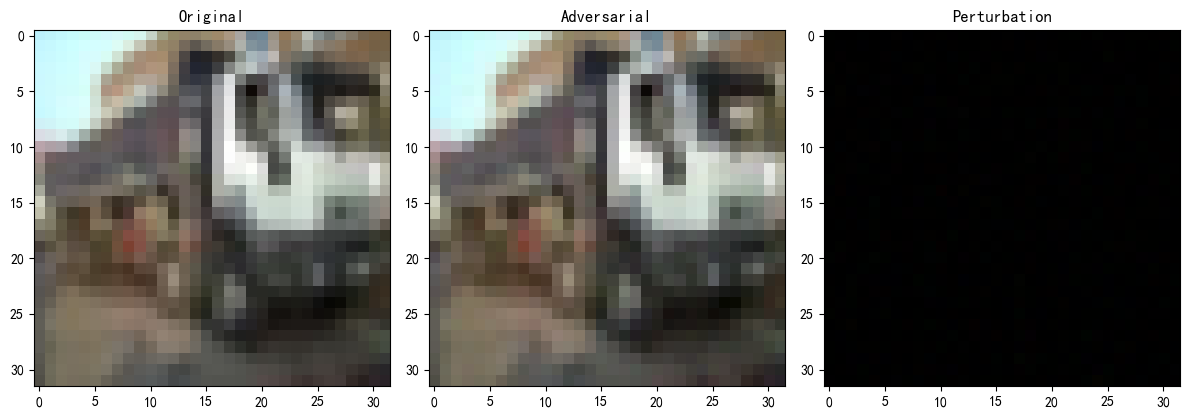

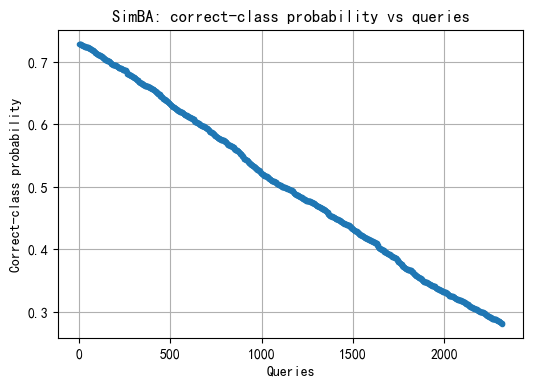

--- 攻击样本 2, 真实标签 9 ---
成功: True, 查询: 1829, L2: 0.2323, L∞: 0.0168


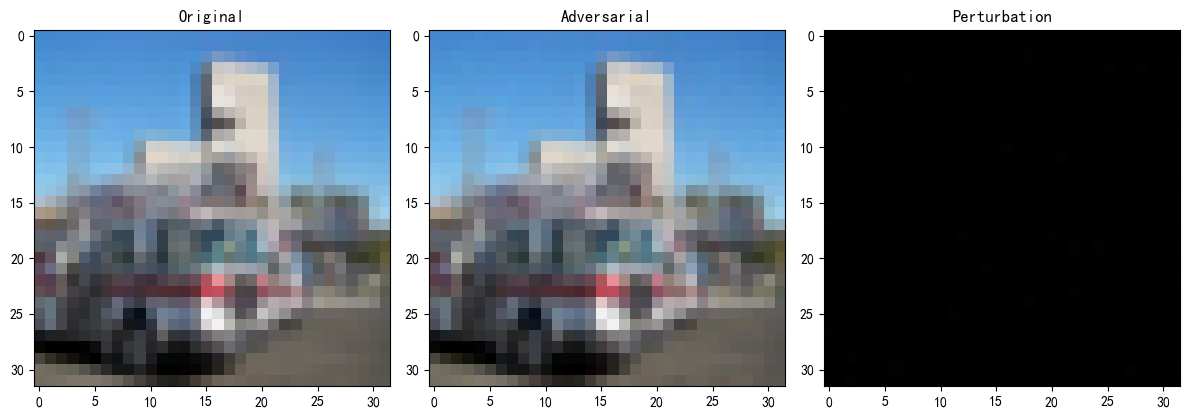

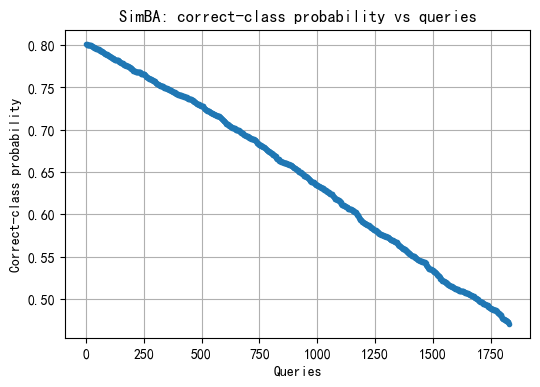

--- 攻击样本 3, 真实标签 3 ---
成功: True, 查询: 3, L2: 0.0078, L∞: 0.0002


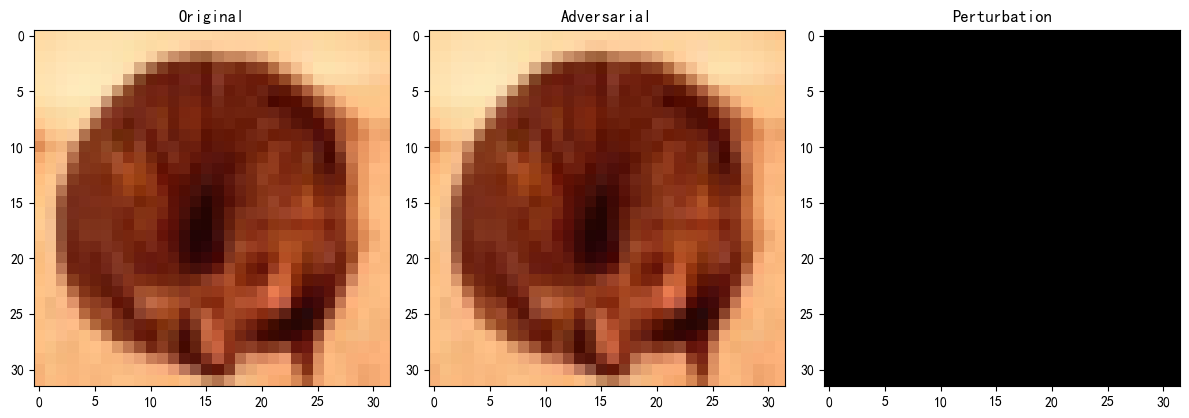

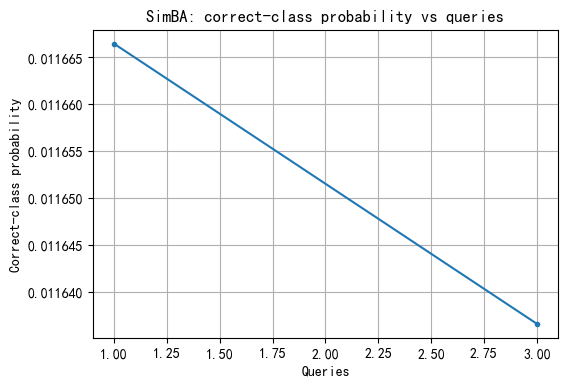

--- 攻击样本 4, 真实标签 9 ---
成功: False, 查询: 6145, L2: 0.4208, L∞: 0.0309
--- 攻击样本 5, 真实标签 0 ---
成功: False, 查询: 6145, L2: 0.4162, L∞: 0.0308
--- 攻击样本 6, 真实标签 7 ---
成功: True, 查询: 5893, L2: 0.4161, L∞: 0.0297


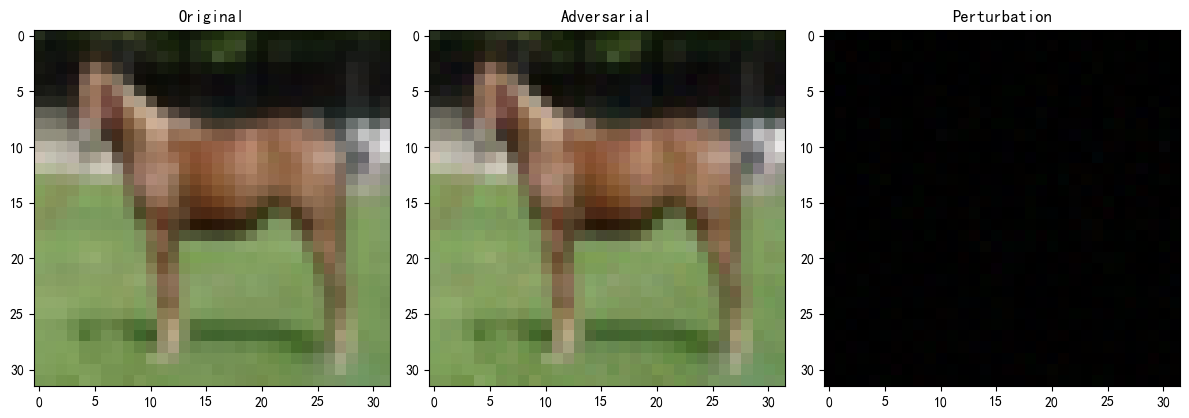

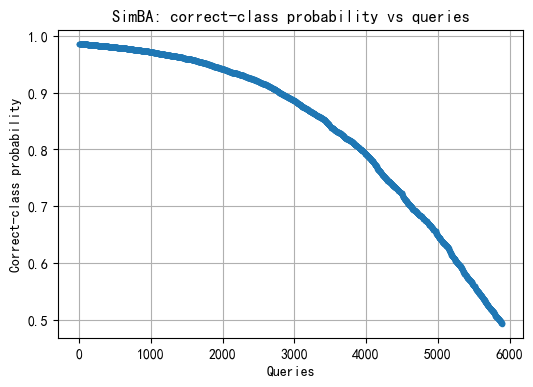

--- 攻击样本 7, 真实标签 8 ---
成功: False, 查询: 6145, L2: 0.4077, L∞: 0.0300
--- 攻击样本 8, 真实标签 1 ---
成功: False, 查询: 6145, L2: 0.4248, L∞: 0.0310
--- 攻击样本 9, 真实标签 9 ---
成功: True, 查询: 3, L2: 0.0078, L∞: 0.0002


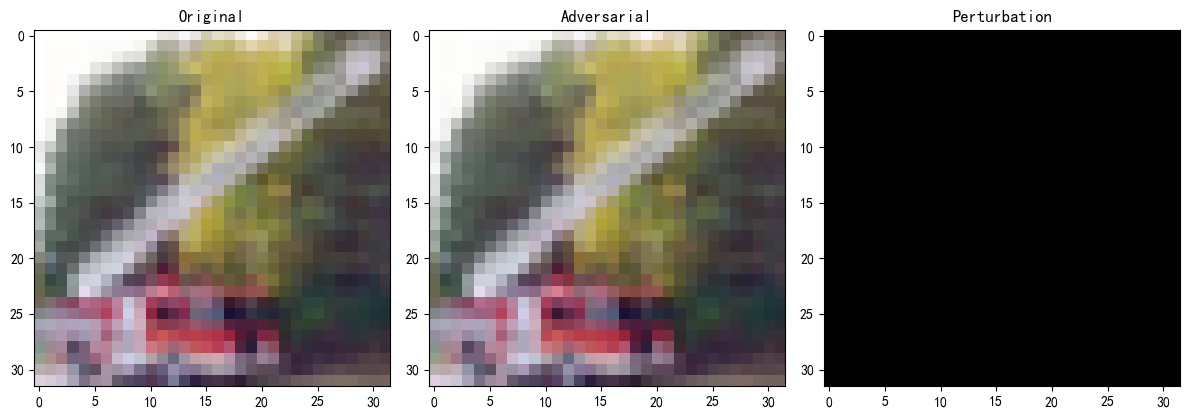

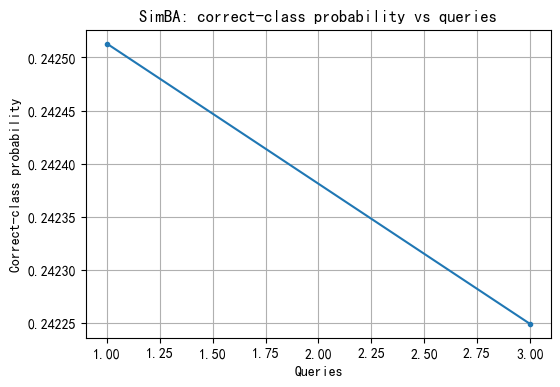

--- 攻击样本 10, 真实标签 2 ---
成功: True, 查询: 3, L2: 0.0078, L∞: 0.0002


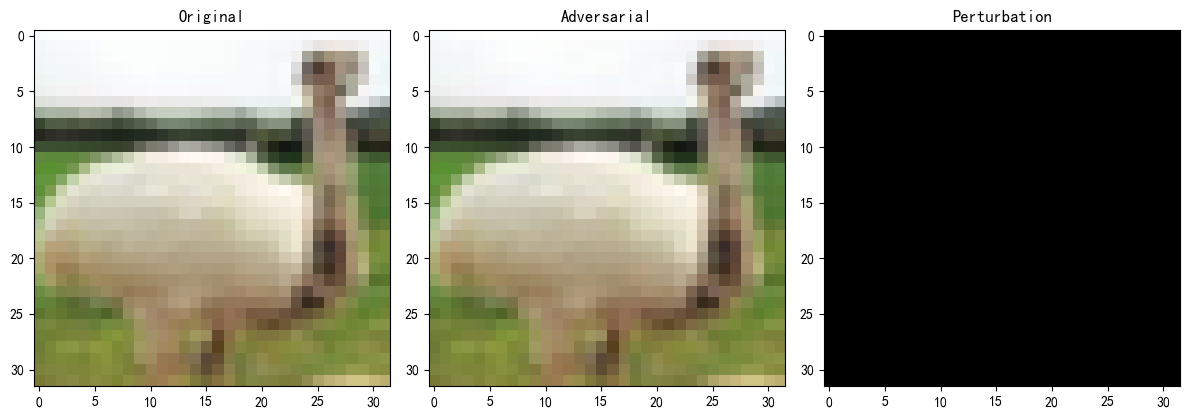

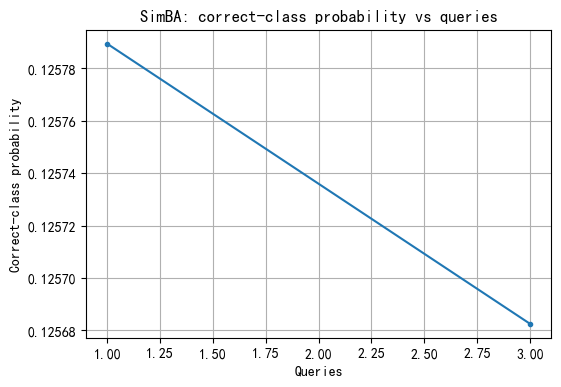


攻击成功率: 60.00%
平均查询次数: 1674.33
平均 L2 扰动: 0.1556
平均 L∞ 扰动: 0.0109


In [3]:
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

def visualize_attack(x, x_adv, query_history, prob_history):
    x_np = x.squeeze(0).permute(1, 2, 0).cpu().numpy()
    x_adv_np = x_adv.squeeze(0).permute(1, 2, 0).cpu().numpy()
    diff = np.abs(x_np - x_adv_np)
    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(np.clip(x_np, 0, 1))
    axs[0].set_title("Original")
    axs[1].imshow(np.clip(x_adv_np, 0, 1))
    axs[1].set_title("Adversarial")
    axs[2].imshow(diff)
    axs[2].set_title("Perturbation")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.plot(query_history, prob_history, marker='o', markersize=3)
    plt.xlabel("Queries")
    plt.ylabel("Correct-class probability")
    plt.title("SimBA: correct-class probability vs queries")
    plt.grid(True)
    plt.show()

num_attacks = 10
successes = 0
queries_list = []
l2_list = []
linf_list = []
for i in range(num_attacks):
    x, y = next(iter(testloader))
    x, y = x.to(attack_device), y.to(attack_device)
    print(f"--- 攻击样本 {i + 1}, 真实标签 {y.item()} ---")
    x_adv, success, queries, l2, linf, q_hist, p_hist = simba_attack(
        x, y, epsilon=2.0 / 255.0, max_linf=8.0 / 255.0, max_iters=5000
    )
    print(f"成功: {success}, 查询: {queries}, L2: {l2:.4f}, L∞: {linf:.4f}")
    if success:
        successes += 1
        queries_list.append(queries)
        l2_list.append(l2)
        linf_list.append(linf)
        visualize_attack(x, x_adv, q_hist, p_hist)

asr = successes / num_attacks * 100
print(f"\n攻击成功率: {asr:.2f}%")
if queries_list:
    print(f"平均查询次数: {np.mean(queries_list):.2f}")
    print(f"平均 L2 扰动: {np.mean(l2_list):.4f}")
    print(f"平均 L∞ 扰动: {np.mean(linf_list):.4f}")


## 结论

SimBA 的核心逻辑非常简单：每次只在单个正交方向上做加减尝试并保留更优方向。它不需要估计梯度、不需要训练替代模型，仅依赖模型输出的置信度即可工作。
由于 DCT 基的能量集中特性，少量低频方向即可显著降低正确类别概率，使得 SimBA 在查询次数和实现复杂度之间取得了极佳平衡。
